In [ ]:
import numpy as np
import pandas as pd
from src.pipeline import ForecasterRecursivePipeline
from src.features import cycle_day_month
from src._catboost import search_params_forecaster_recursive
from functools import partial
import warnings
from skforecast.exceptions import IgnoredArgumentWarning

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

In [ ]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

optimized_search = partial(search_params_forecaster_recursive, n_trials=10)

exog_cols = ['Месяц_sin', 'Месяц_cos', 'День_sin', 'День_cos', 'days_from_start']
start_date = '2020-11-27'
val_split_date = '2024-01-01'

In [4]:
def feature_transform(df: pd.DataFrame, start_date: str):
    df = df.copy()
    df = cycle_day_month(df)
    
    start_date = pd.to_datetime(start_date)
    df['days_from_start'] = (df['Дата'] - start_date).dt.days
    
    df = df.drop(columns=['Дата'])

    return df

[I 2026-05-11 16:06:36,742] A new study created in memory with name: no-name-f52085a5-6edd-40e1-b0a2-b18fdeb4c7a5
[I 2026-05-11 16:06:38,601] Trial 0 finished with value: 3.5434054143005325 and parameters: {'lags': 1, 'iterations': 1802, 'learning_rate': 0.003015053939148674, 'depth': 4, 'l2_leaf_reg': 5.107586343224293, 'subsample': 0.5202265632038161, 'colsample_bylevel': 0.586570941161945, 'min_data_in_leaf': 28, 'random_strength': 0.016912458436476308}. Best is trial 0 with value: 3.5434054143005325.
[I 2026-05-11 16:06:54,447] Trial 1 finished with value: 3.5841079269761984 and parameters: {'lags': 5, 'iterations': 1133, 'learning_rate': 0.01759728923778438, 'depth': 10, 'l2_leaf_reg': 2.0751526506652596, 'subsample': 0.6644673050424525, 'colsample_bylevel': 0.8810585098279275, 'min_data_in_leaf': 11, 'random_strength': 0.0105641672165742}. Best is trial 0 with value: 3.5434054143005325.
[I 2026-05-11 16:06:56,062] Trial 2 finished with value: 3.752839703067882 and parameters: {'l

RMSE на тестовых данных: 2.811249148211958


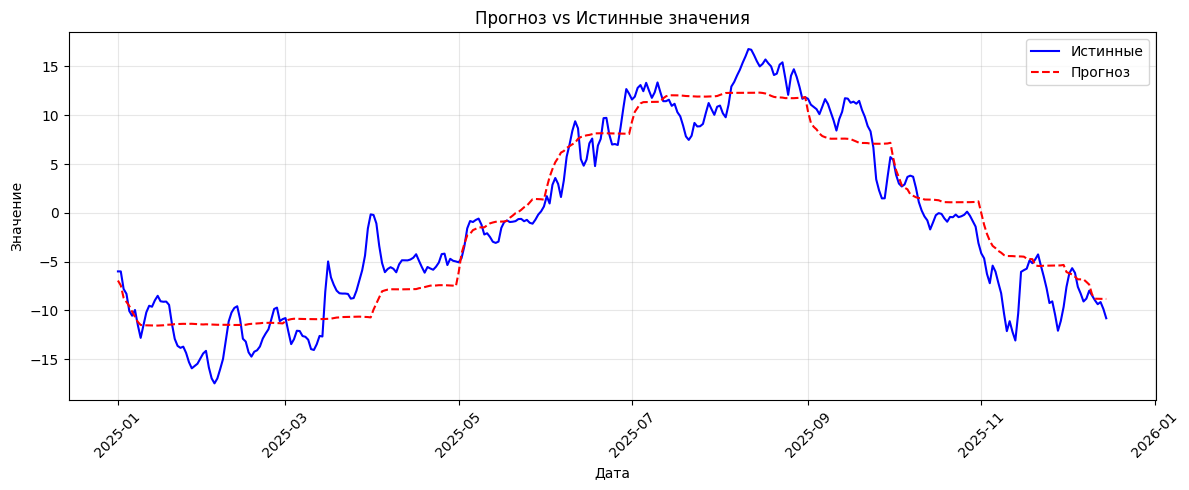

[I 2026-05-11 16:09:25,297] A new study created in memory with name: no-name-38d7ddb2-222d-4d24-bbed-5bfef8e94700
[I 2026-05-11 16:09:27,025] Trial 0 finished with value: 3.1672356397009254 and parameters: {'lags': 1, 'iterations': 1127, 'learning_rate': 0.0060425004091243534, 'depth': 5, 'l2_leaf_reg': 5.424929242163391, 'subsample': 0.7855716367458021, 'colsample_bylevel': 0.8324687254222588, 'min_data_in_leaf': 5, 'random_strength': 0.08027989473589117}. Best is trial 0 with value: 3.1672356397009254.
[I 2026-05-11 16:09:28,878] Trial 1 finished with value: 4.83971737634671 and parameters: {'lags': 4, 'iterations': 1846, 'learning_rate': 0.11716196544868851, 'depth': 4, 'l2_leaf_reg': 0.00557242388760379, 'subsample': 0.46746371587251806, 'colsample_bylevel': 0.9835128329328334, 'min_data_in_leaf': 21, 'random_strength': 0.0010521692539415927}. Best is trial 0 with value: 3.1672356397009254.
[I 2026-05-11 16:09:31,054] Trial 2 finished with value: 3.4242097363057478 and parameters: 

RMSE на тестовых данных: 3.1071575657111272


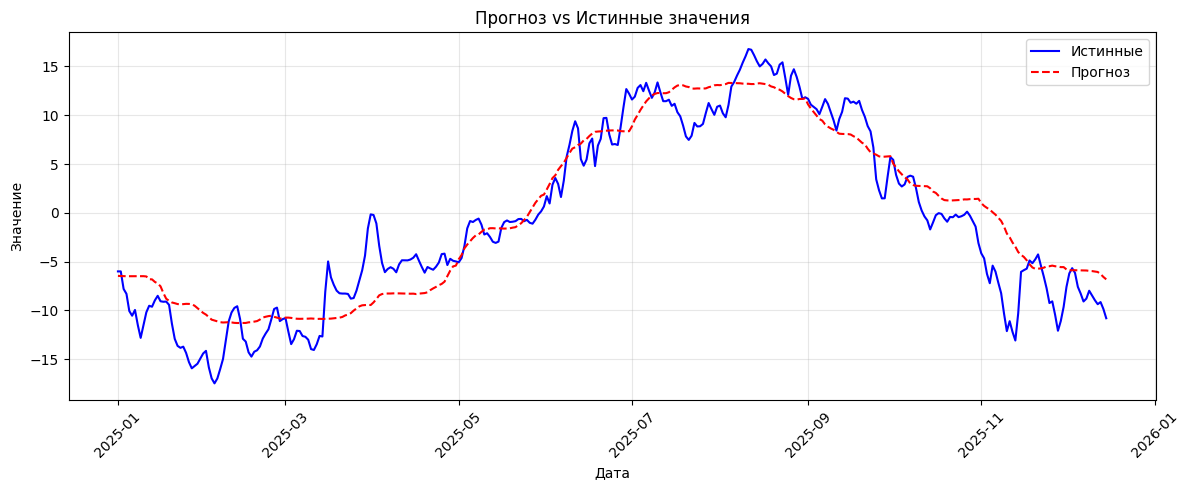

In [31]:
depth = 0
model_path = f'../catboost/models/catboost_v1_{depth}'
target_col = f'48-1 ({depth})'
catboost_pipeline = ForecasterRecursivePipeline(
    model_name='catboost',
    target_col=target_col,
    exog_cols=exog_cols,
    val_split_date=val_split_date,
    start_date=start_date,
    feature_transform_func=feature_transform,
    optimize_func=optimized_search,
    clean_outliers=False)

catboost_pipeline.run_pipeline(df_train_full, df_test)

catboost_pipeline_clean_outliers = ForecasterRecursivePipeline(
    model_name='catboost',
    target_col=target_col,
    exog_cols=exog_cols,
    val_split_date=val_split_date,
    start_date=start_date,
    feature_transform_func=feature_transform,
    optimize_func=optimized_search,
    clean_outliers=True)

catboost_pipeline_clean_outliers.run_pipeline(df_train_full, df_test)

In [ ]:
# без очистки выбросов
catboost_pipeline.save_model(model_path)

Модель сохранена: ../catboost/models/catboost_v1_0


[I 2026-05-11 16:11:26,148] A new study created in memory with name: no-name-5f2827b4-8b5e-427a-9859-d79af8234795
[I 2026-05-11 16:11:28,982] Trial 0 finished with value: 2.14616727596158 and parameters: {'lags': 6, 'iterations': 183, 'learning_rate': 0.001169558310020018, 'depth': 10, 'l2_leaf_reg': 0.35744182961551807, 'subsample': 0.6966016171987482, 'colsample_bylevel': 0.7047092113906066, 'min_data_in_leaf': 12, 'random_strength': 0.07531629204775497}. Best is trial 0 with value: 2.14616727596158.
[I 2026-05-11 16:11:51,863] Trial 1 finished with value: 1.7817644673560675 and parameters: {'lags': 7, 'iterations': 421, 'learning_rate': 0.263776628164503, 'depth': 12, 'l2_leaf_reg': 0.011740116144755583, 'subsample': 0.6074116238011341, 'colsample_bylevel': 0.8600974669293411, 'min_data_in_leaf': 18, 'random_strength': 0.003225707814015226}. Best is trial 1 with value: 1.7817644673560675.
[I 2026-05-11 16:11:53,359] Trial 2 finished with value: 1.1592789423901093 and parameters: {'l

RMSE на тестовых данных: 0.6059671152485869


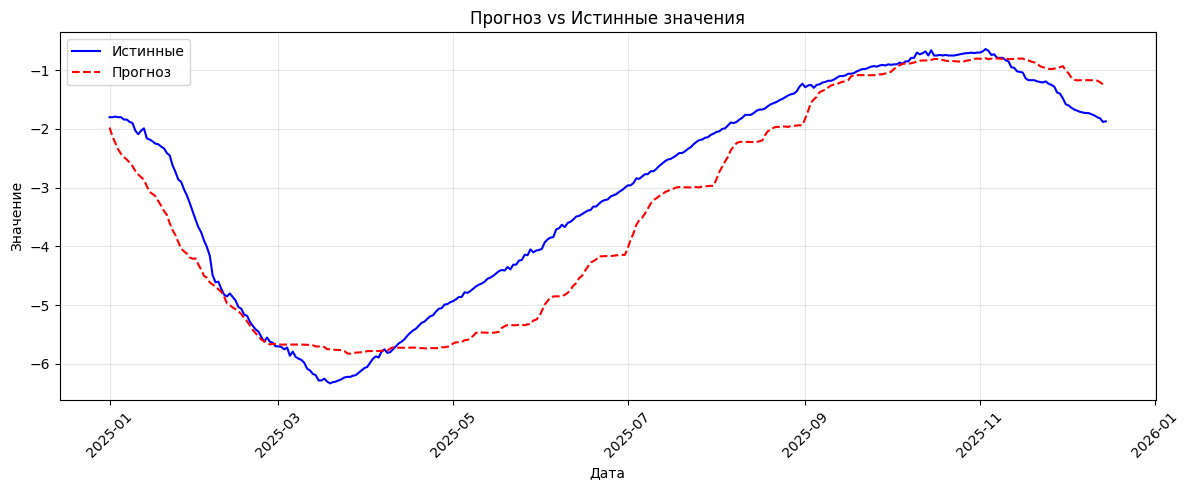

[I 2026-05-11 16:13:28,645] A new study created in memory with name: no-name-610bf0a2-9587-441d-9555-b9bccbd06d29
[I 2026-05-11 16:13:30,943] Trial 0 finished with value: 2.7470878013010394 and parameters: {'lags': 9, 'iterations': 963, 'learning_rate': 0.2546083641490573, 'depth': 6, 'l2_leaf_reg': 0.34788152148685464, 'subsample': 0.8282629870616944, 'colsample_bylevel': 0.8630886189190087, 'min_data_in_leaf': 18, 'random_strength': 0.00547136786198076}. Best is trial 0 with value: 2.7470878013010394.
[I 2026-05-11 16:14:16,801] Trial 1 finished with value: 1.7916961698508524 and parameters: {'lags': 9, 'iterations': 885, 'learning_rate': 0.06872068194055672, 'depth': 12, 'l2_leaf_reg': 5.505505425274546, 'subsample': 0.9581597410059479, 'colsample_bylevel': 0.7014344104202788, 'min_data_in_leaf': 11, 'random_strength': 0.006421990044831223}. Best is trial 1 with value: 1.7916961698508524.
[I 2026-05-11 16:14:18,037] Trial 2 finished with value: 1.3038901943358012 and parameters: {'l

RMSE на тестовых данных: 0.5932988705357913


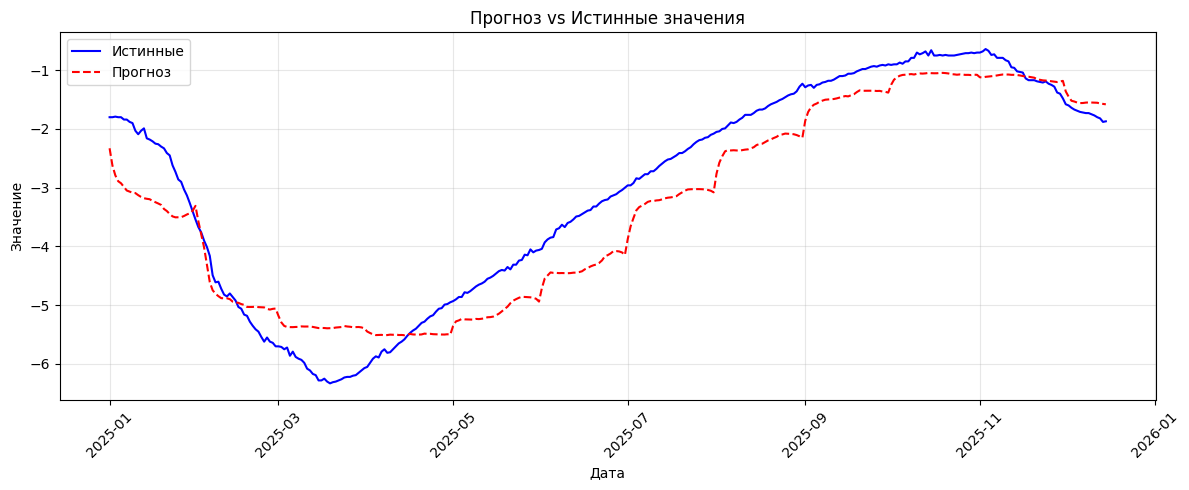

In [33]:
depth = 5
model_path = f'../catboost/models/catboost_v1_{depth}'
target_col = f'48-1 ({depth})'
catboost_pipeline = ForecasterRecursivePipeline(
    model_name='catboost',
    target_col=target_col,
    exog_cols=exog_cols,
    val_split_date=val_split_date,
    start_date=start_date,
    feature_transform_func=feature_transform,
    optimize_func=optimized_search,
    clean_outliers=False)

catboost_pipeline.run_pipeline(df_train_full, df_test)

catboost_pipeline_clean_outliers = ForecasterRecursivePipeline(
    model_name='catboost',
    target_col=target_col,
    exog_cols=exog_cols,
    val_split_date=val_split_date,
    start_date=start_date,
    feature_transform_func=feature_transform,
    optimize_func=optimized_search,
    clean_outliers=True)

catboost_pipeline_clean_outliers.run_pipeline(df_train_full, df_test)

In [ ]:
# с очисткой выбросов
catboost_pipeline_clean_outliers.save_model(model_path)

Модель сохранена: ../catboost/models/catboost_v1_5


[I 2026-05-11 16:17:19,075] A new study created in memory with name: no-name-4032e3bf-f7f7-4261-a4da-f50560575ca5
[I 2026-05-11 16:17:33,950] Trial 0 finished with value: 0.6288459194261041 and parameters: {'lags': 5, 'iterations': 1062, 'learning_rate': 0.026762253030482748, 'depth': 10, 'l2_leaf_reg': 0.004214891037555642, 'subsample': 0.4532761721863149, 'colsample_bylevel': 0.9066504169651913, 'min_data_in_leaf': 25, 'random_strength': 0.009547826417907104}. Best is trial 0 with value: 0.6288459194261041.
[I 2026-05-11 16:17:35,882] Trial 1 finished with value: 0.3509798090864628 and parameters: {'lags': 7, 'iterations': 1619, 'learning_rate': 0.05175596610544559, 'depth': 4, 'l2_leaf_reg': 1.3560219258380528, 'subsample': 0.45593453467803224, 'colsample_bylevel': 0.4029221097237484, 'min_data_in_leaf': 18, 'random_strength': 0.008484087155183347}. Best is trial 1 with value: 0.3509798090864628.
[I 2026-05-11 16:17:38,420] Trial 2 finished with value: 0.6746253327119425 and paramet

RMSE на тестовых данных: 0.39332150486609285


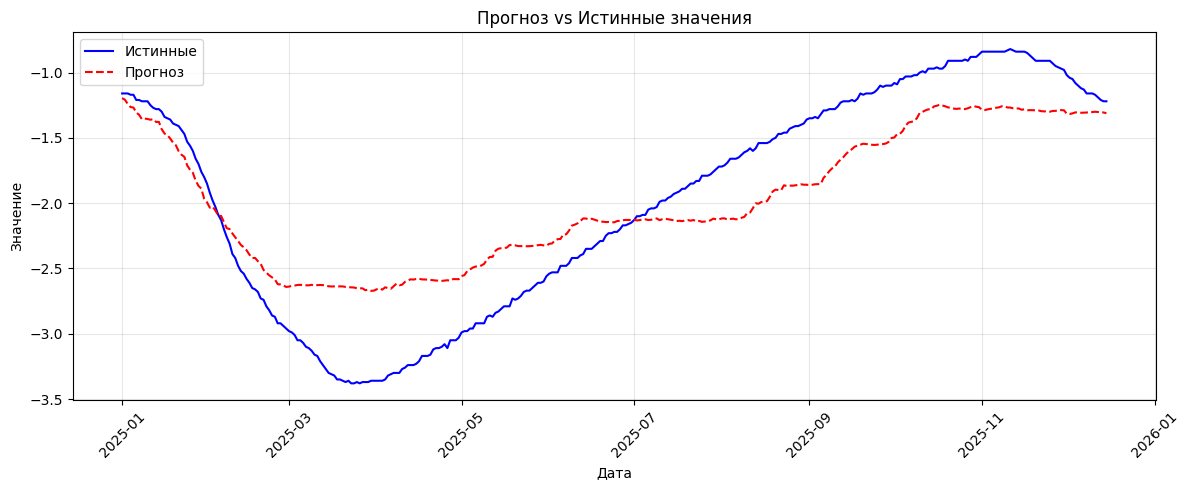

[I 2026-05-11 16:20:40,798] A new study created in memory with name: no-name-9a913cd6-7d49-48af-88c3-af3e10a47f72
[I 2026-05-11 16:20:41,788] Trial 0 finished with value: 0.478842285123198 and parameters: {'lags': 7, 'iterations': 537, 'learning_rate': 0.023840108047195142, 'depth': 4, 'l2_leaf_reg': 6.802644288586663, 'subsample': 0.46609696642565535, 'colsample_bylevel': 0.8113440845886004, 'min_data_in_leaf': 23, 'random_strength': 2.699959201309128}. Best is trial 0 with value: 0.478842285123198.
[I 2026-05-11 16:20:44,211] Trial 1 finished with value: 0.39529539517331924 and parameters: {'lags': 10, 'iterations': 1927, 'learning_rate': 0.02076125720554951, 'depth': 4, 'l2_leaf_reg': 0.35550018304493336, 'subsample': 0.9981747613053767, 'colsample_bylevel': 0.8583630697177373, 'min_data_in_leaf': 3, 'random_strength': 0.27496746443444614}. Best is trial 1 with value: 0.39529539517331924.
[I 2026-05-11 16:20:45,704] Trial 2 finished with value: 0.40080475126789783 and parameters: {'

RMSE на тестовых данных: 0.19101509296610467


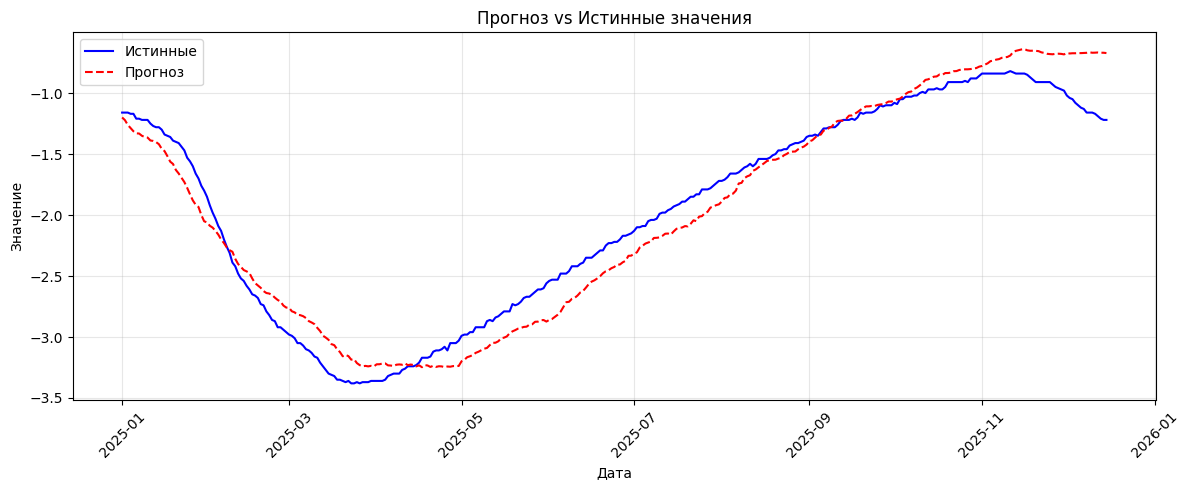

In [35]:
depth = 10
model_path = f'../catboost/models/catboost_v1_{depth}'
target_col = f'48-1 ({depth})'
catboost_pipeline = ForecasterRecursivePipeline(
    model_name='catboost',
    target_col=target_col,
    exog_cols=exog_cols,
    val_split_date=val_split_date,
    start_date=start_date,
    feature_transform_func=feature_transform,
    optimize_func=optimized_search,
    clean_outliers=False)

catboost_pipeline.run_pipeline(df_train_full, df_test)

catboost_pipeline_clean_outliers = ForecasterRecursivePipeline(
    model_name='catboost',
    target_col=target_col,
    exog_cols=exog_cols,
    val_split_date=val_split_date,
    start_date=start_date,
    feature_transform_func=feature_transform,
    optimize_func=optimized_search,
    clean_outliers=True)

catboost_pipeline_clean_outliers.run_pipeline(df_train_full, df_test)

In [ ]:
# с очисткой выбросов
catboost_pipeline_clean_outliers.save_model(model_path)

Модель сохранена: ../catboost/models/catboost_v1_10


[I 2026-05-11 20:13:15,738] A new study created in memory with name: no-name-fbe75301-500d-4a86-99ce-6f8d2c5f261c
[I 2026-05-11 20:13:16,916] Trial 0 finished with value: 1.4393635464097096 and parameters: {'lags': 10, 'iterations': 237, 'learning_rate': 0.03954422066772408, 'depth': 6, 'l2_leaf_reg': 0.007331658390572107, 'subsample': 0.7627301777398364, 'colsample_bylevel': 0.813149259806254, 'min_data_in_leaf': 5, 'random_strength': 0.019770706294177164}. Best is trial 0 with value: 1.4393635464097096.
[I 2026-05-11 20:13:22,050] Trial 1 finished with value: 1.1465270474975544 and parameters: {'lags': 1, 'iterations': 338, 'learning_rate': 0.00974275962849077, 'depth': 11, 'l2_leaf_reg': 0.002423382947698822, 'subsample': 0.7501048120232625, 'colsample_bylevel': 0.8292231394356451, 'min_data_in_leaf': 25, 'random_strength': 3.2097333699397113}. Best is trial 1 with value: 1.1465270474975544.
[I 2026-05-11 20:14:37,415] Trial 2 finished with value: 1.409389310115193 and parameters: {

RMSE на тестовых данных: 0.580705606315816


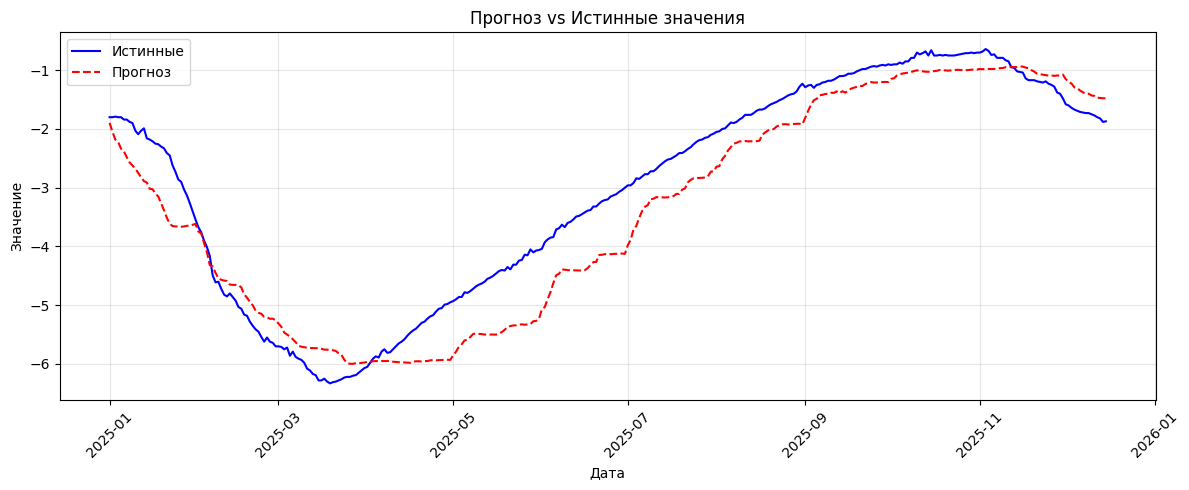

[I 2026-05-11 20:18:08,451] A new study created in memory with name: no-name-cca3e3ba-dc7a-4f22-bf76-70102d20d658
[I 2026-05-11 20:18:09,156] Trial 0 finished with value: 0.668369361298875 and parameters: {'lags': 2, 'iterations': 424, 'learning_rate': 0.018025159061795856, 'depth': 3, 'l2_leaf_reg': 0.0046226682433609745, 'subsample': 0.9180804307784496, 'colsample_bylevel': 0.49506647802075887, 'min_data_in_leaf': 3, 'random_strength': 0.0016557139258779835}. Best is trial 0 with value: 0.668369361298875.
[I 2026-05-11 20:18:10,478] Trial 1 finished with value: 0.9835999347569545 and parameters: {'lags': 1, 'iterations': 1828, 'learning_rate': 0.02240342693223337, 'depth': 2, 'l2_leaf_reg': 0.043660451701134334, 'subsample': 0.9688627511691275, 'colsample_bylevel': 0.6797441630705165, 'min_data_in_leaf': 7, 'random_strength': 6.328111126519534}. Best is trial 0 with value: 0.668369361298875.
[I 2026-05-11 20:18:11,775] Trial 2 finished with value: 1.691535354524736 and parameters: {'

RMSE на тестовых данных: 0.7297200350908137


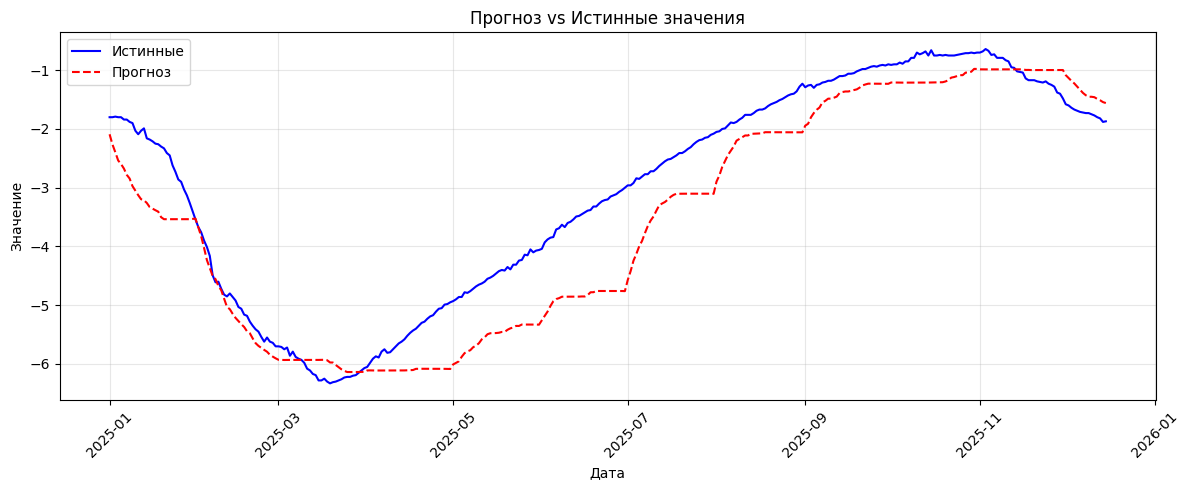

In [ ]:
optimized_search = partial(search_params_forecaster_recursive, n_trials=30)
depth = 5
model_path = f'../catboost/models/catboost_v1_{depth}'
target_col = f'48-1 ({depth})'
catboost_pipeline = ForecasterRecursivePipeline(
    model_name='catboost',
    target_col=target_col,
    exog_cols=exog_cols,
    val_split_date=val_split_date,
    start_date=start_date,
    feature_transform_func=feature_transform,
    optimize_func=optimized_search,
    clean_outliers=False)

catboost_pipeline.run_pipeline(df_train_full, df_test)

catboost_pipeline_clean_outliers = ForecasterRecursivePipeline(
    model_name='catboost',
    target_col=target_col,
    exog_cols=exog_cols,
    val_split_date=val_split_date,
    start_date=start_date,
    feature_transform_func=feature_transform,
    optimize_func=optimized_search,
    clean_outliers=True)

catboost_pipeline_clean_outliers.run_pipeline(df_train_full, df_test)

In [6]:
catboost_pipeline.save_model(model_path)

Модель сохранена: ../catboost/models/catboost_v1_5
